## Data Loading and Overview of Tables

In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from sqlalchemy import create_engine, text

host = "34.171.67.51"
port = 3306
user = "root"
password = "Toronto123"

connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/"

engine = create_engine(
    connection_string,
    connect_args={"connect_timeout": 10}
)

In [3]:
schemas = pd.read_sql("SHOW DATABASES;", engine)
schemas

,Database
0,energy
1,information_schema
2,mysql
3,performance_schema
4,raw
5,staging
6,sys


In [54]:
staging_tables = pd.read_sql(
    "SHOW TABLES IN staging;",
    engine
)

staging_tables

,Tables_in_staging
0,stg_calendar_holidays
1,stg_eia_natural_gas_prices
2,stg_ercot_dam_prices
3,stg_ercot_fuel_mix
4,stg_ercot_region_hourly
5,stg_nrel_solar_resource
6,stg_nrel_wind_resource
7,stg_weather_texas_hourly


In [9]:
energy_tables = pd.read_sql(
    "SHOW TABLES IN energy;",
    engine
)

energy_tables

,Tables_in_energy
0,calendar_date
1,calendar_holiday
2,ercot_dam_price
3,ercot_fuel_mix_hourly
4,ercot_region_hourly_metric
5,ercot_settlement_point
6,holiday
7,natural_gas_daily_price
8,nrel_solar_resource_hourly
9,nrel_wind_resource_hourly


In [10]:
raw_tables = pd.read_sql(
    "SHOW TABLES IN raw;",
    engine
)

raw_tables

,Tables_in_raw
0,raw_calendar_holidays
1,raw_eia_natural_gas_prices_2025
2,raw_ercot_dam_prices
3,raw_ercot_demand_forecast
4,raw_ercot_fuel_mix
5,raw_ercot_hourly_interchange
6,raw_ercot_hourly_load
7,raw_nrel_solar_resource
8,raw_nrel_wind_resource
9,raw_weather_texas_hourly


## EDA 

#### Base functions

In [55]:
def preview_table(schema, table, limit=5):
    query = f"""
    SELECT *
    FROM {schema}.{table}
    LIMIT {limit}
    """
    
    return pd.read_sql(query, engine)

In [56]:
def describe_table(schema, table):
    query = f"""
    DESCRIBE {schema}.{table}
    """
    
    return pd.read_sql(query, engine)

In [57]:
def missing_summary(df):
    missing = (
        df.isnull()
          .mean()
          .sort_values(ascending=False)
          * 100
    )
    
    return missing

#### Tables / Overview

In [58]:
describe_table("staging", "stg_ercot_dam_prices")

,Field,Type,Null,Key,Default,Extra
0,dam_price_key,int,NO,PRI,None,auto_increment
1,datetime_hour,datetime,YES,,None,
2,date_key,bigint,YES,,None,
3,delivery_date,datetime,YES,,None,
4,hour_start,bigint,YES,,None,
5,hour_ending,bigint,YES,,None,
6,is_repeated_hour,bigint,YES,,None,
7,settlement_point,text,YES,,None,
8,settlement_point_price,double,YES,,None,
9,source_year,bigint,YES,,None,


In [15]:
df = pd.read_sql("""
SELECT *
FROM staging.stg_ercot_dam_prices
LIMIT 10000
""", engine)

df.head()

,dam_price_key,datetime_hour,date_key,delivery_date,hour_start,hour_ending,is_repeated_hour,settlement_point,settlement_point_price,source_year
0,1,2025-01-01 00:00:00,20250101,2025-01-01,0,1,0,HB_BUSAVG,23.00,2025
1,2,2025-01-01 00:00:00,20250101,2025-01-01,0,1,0,HB_HOUSTON,22.87,2025
2,3,2025-01-01 05:00:00,20250101,2025-01-01,5,6,0,HB_WEST,25.71,2025
3,4,2025-01-01 00:00:00,20250101,2025-01-01,0,1,0,HB_HUBAVG,23.07,2025
4,5,2025-01-01 05:00:00,20250101,2025-01-01,5,6,0,LZ_AEN,23.45,2025


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   dam_price_key           10000 non-null  int64         
 1   datetime_hour           10000 non-null  datetime64[ns]
 2   date_key                10000 non-null  int64         
 3   delivery_date           10000 non-null  datetime64[ns]
 4   hour_start              10000 non-null  int64         
 5   hour_ending             10000 non-null  int64         
 6   is_repeated_hour        10000 non-null  int64         
 7   settlement_point        10000 non-null  object        
 8   settlement_point_price  10000 non-null  float64       
 9   source_year             10000 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(6), object(1)
memory usage: 781.4+ KB


In [17]:
df.describe()

,dam_price_key,datetime_hour,date_key,delivery_date,hour_start,hour_ending,is_repeated_hour,settlement_point_price,source_year
count,10000.00000,10000,1.000000e+04,10000,10000.000000,10000.000000,10000.0,10000.000000,10000.0
mean,5000.50000,2025-01-14 20:58:57,2.025011e+07,2025-01-14 09:32:24.000000256,11.442500,12.442500,0.0,32.443155,2025.0
min,1.00000,2025-01-01 00:00:00,2.025010e+07,2025-01-01 00:00:00,0.000000,1.000000,0.0,-12.220000,2025.0
25%,2500.75000,2025-01-07 22:00:00,2.025011e+07,2025-01-07 00:00:00,5.000000,6.000000,0.0,21.190000,2025.0
50%,5000.50000,2025-01-14 21:00:00,2.025011e+07,2025-01-14 00:00:00,11.000000,12.000000,0.0,27.665000,2025.0
75%,7500.25000,2025-01-21 19:15:00,2.025012e+07,2025-01-21 00:00:00,17.000000,18.000000,0.0,39.655000,2025.0
max,10000.00000,2025-01-29 10:00:00,2.025013e+07,2025-01-29 00:00:00,23.000000,24.000000,0.0,232.920000,2025.0
std,2886.89568,NaN,8.028944e+00,NaN,6.931818,6.931818,0.0,22.489016,0.0


In [18]:
missing_summary(df)

dam_price_key             0.0
datetime_hour             0.0
date_key                  0.0
delivery_date             0.0
hour_start                0.0
hour_ending               0.0
is_repeated_hour          0.0
settlement_point          0.0
settlement_point_price    0.0
source_year               0.0
dtype: float64

In [19]:
df.nunique().sort_values(ascending=False)

dam_price_key             10000
settlement_point_price     4926
datetime_hour               670
date_key                     29
delivery_date                29
hour_start                   24
hour_ending                  24
settlement_point             15
is_repeated_hour              1
source_year                   1
dtype: int64

In [20]:
df.columns

Index(['dam_price_key', 'datetime_hour', 'date_key', 'delivery_date',
       'hour_start', 'hour_ending', 'is_repeated_hour', 'settlement_point',
       'settlement_point_price', 'source_year'],
      dtype='object')

#### Missingness

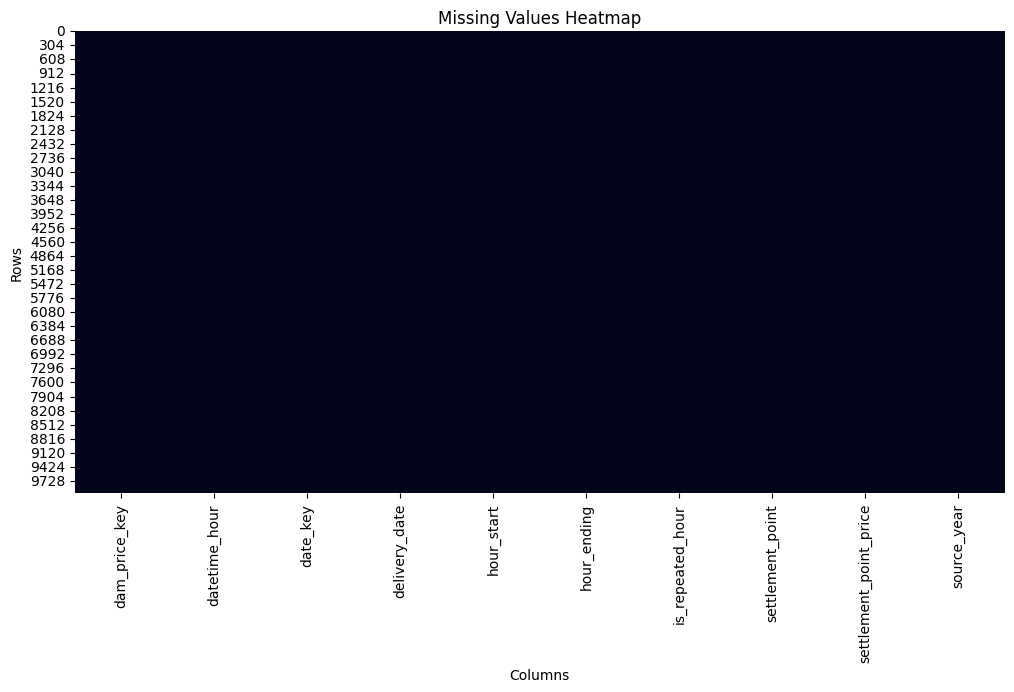

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

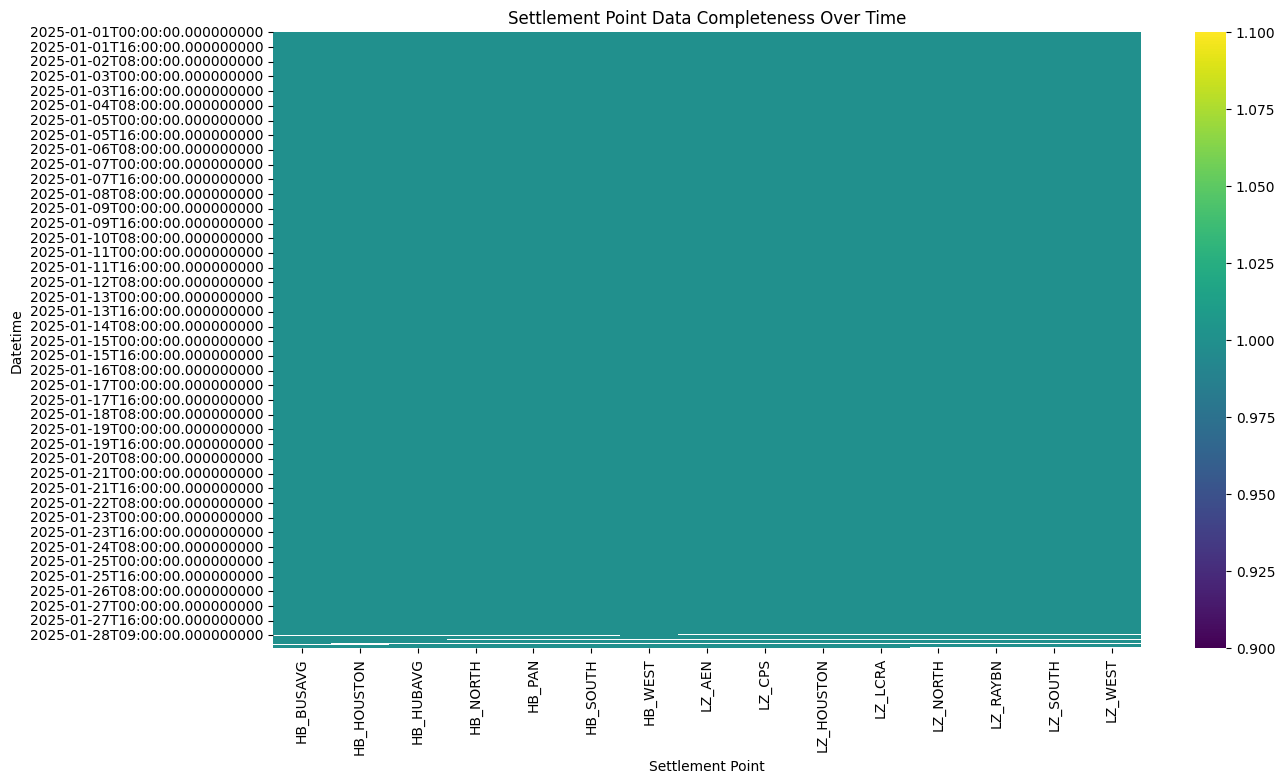

In [22]:
completeness = df.pivot_table(
    index='datetime_hour',
    columns='settlement_point',
    values='settlement_point_price',
    aggfunc='count'
)
plt.figure(figsize=(14,8))

sns.heatmap(
    completeness,
    cmap='viridis'
)

plt.title("Settlement Point Data Completeness Over Time")
plt.xlabel("Settlement Point")
plt.ylabel("Datetime")

plt.show()

In [23]:
expected = (
    df['datetime_hour'].nunique()
    * df['settlement_point'].nunique()
)

actual = len(df)

print("Expected:", expected)
print("Actual:", actual)
print("Missing:", expected - actual)

Expected: 10050
Actual: 10000
Missing: 50


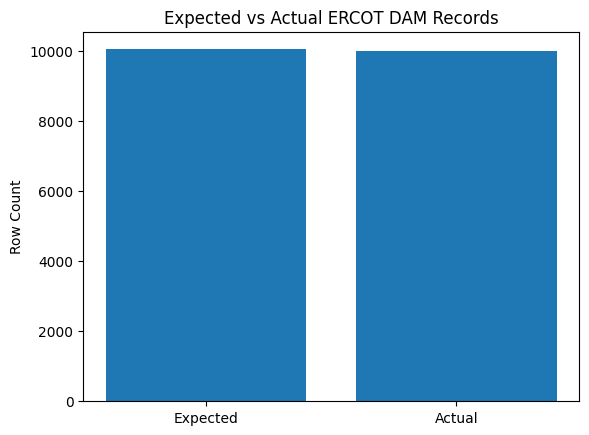

In [24]:
plt.bar(
    ['Expected', 'Actual'],
    [expected, actual]
)

plt.title("Expected vs Actual ERCOT DAM Records")
plt.ylabel("Row Count")

plt.show()

In [25]:
daily_counts = pd.read_sql("""
SELECT
    delivery_date,
    COUNT(*) AS record_count
FROM staging.stg_ercot_dam_prices
GROUP BY delivery_date
ORDER BY delivery_date
""", engine)

In [26]:
EXPECTED_PER_DAY = 24 * 15

daily_counts['expected'] = EXPECTED_PER_DAY

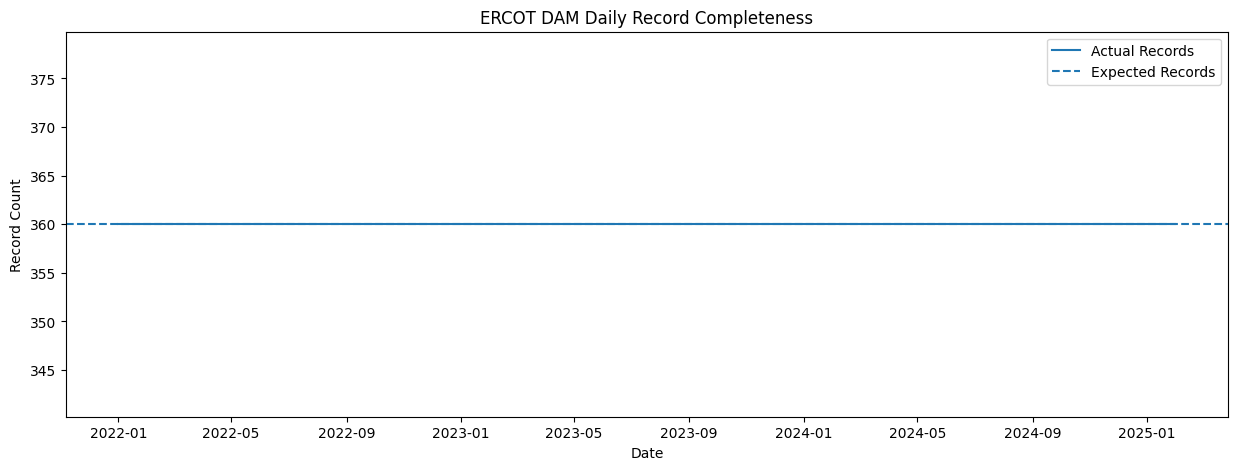

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_counts['delivery_date'],
    daily_counts['record_count'],
    label='Actual Records'
)

plt.axhline(
    EXPECTED_PER_DAY,
    linestyle='--',
    label='Expected Records'
)

plt.title("ERCOT DAM Daily Record Completeness")
plt.xlabel("Date")
plt.ylabel("Record Count")

plt.legend()

plt.show()

In [28]:
daily_counts['pct_complete'] = (
    daily_counts['record_count']
    / EXPECTED_PER_DAY
) * 100

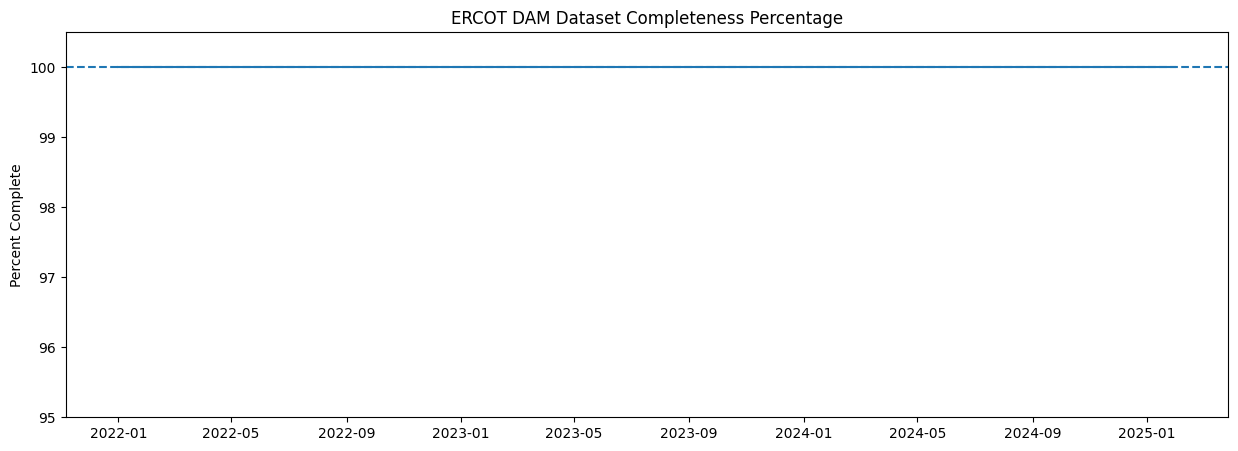

In [29]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_counts['delivery_date'],
    daily_counts['pct_complete']
)

plt.axhline(
    100,
    linestyle='--'
)

plt.title("ERCOT DAM Dataset Completeness Percentage")
plt.ylabel("Percent Complete")
plt.ylim(95, 100.5)

plt.show()

#### Data Overview

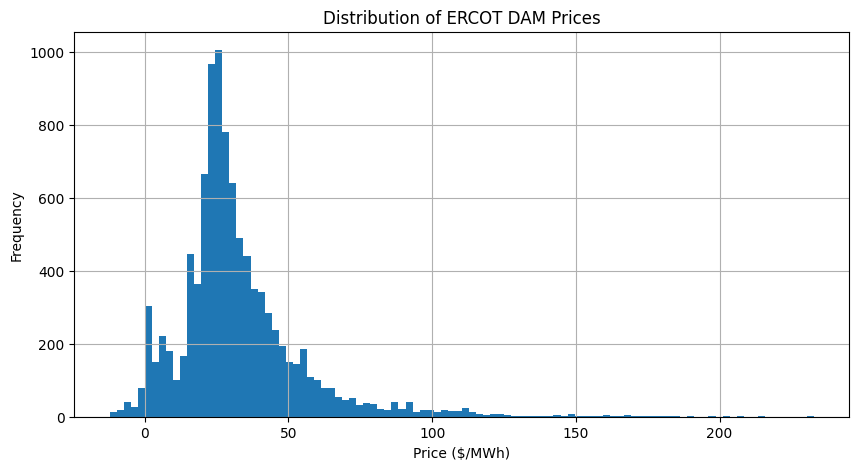

In [30]:
plt.figure(figsize=(10,5))

df['settlement_point_price'].hist(
    bins=100
)

plt.title("Distribution of ERCOT DAM Prices")
plt.xlabel("Price ($/MWh)")
plt.ylabel("Frequency")

plt.show()

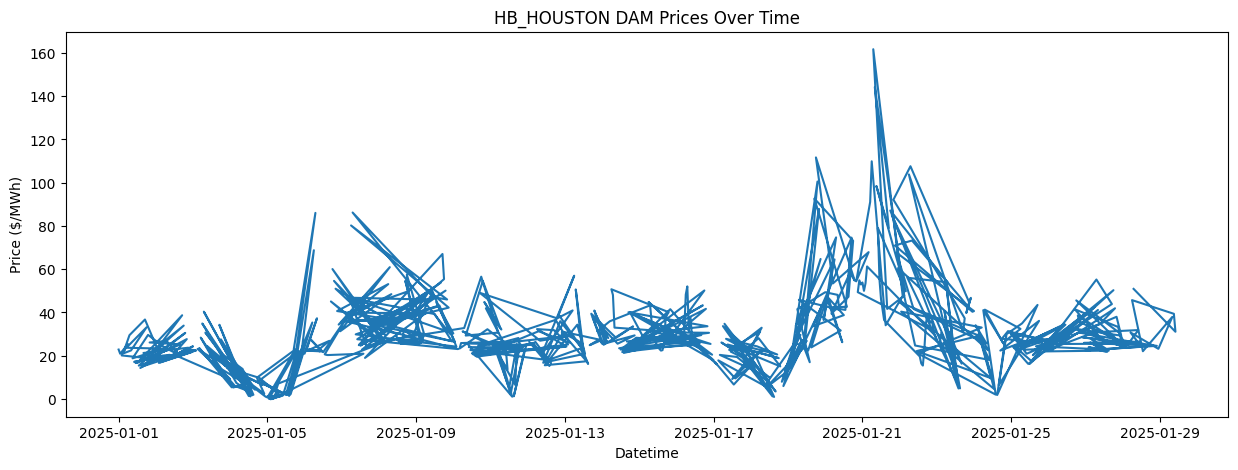

In [31]:
houston = df[
    df['settlement_point'] == 'HB_HOUSTON'
]

plt.figure(figsize=(15,5))

plt.plot(
    houston['datetime_hour'],
    houston['settlement_point_price']
)

plt.title("HB_HOUSTON DAM Prices Over Time")
plt.xlabel("Datetime")
plt.ylabel("Price ($/MWh)")

plt.show()

<Figure size 1200x600 with 0 Axes>

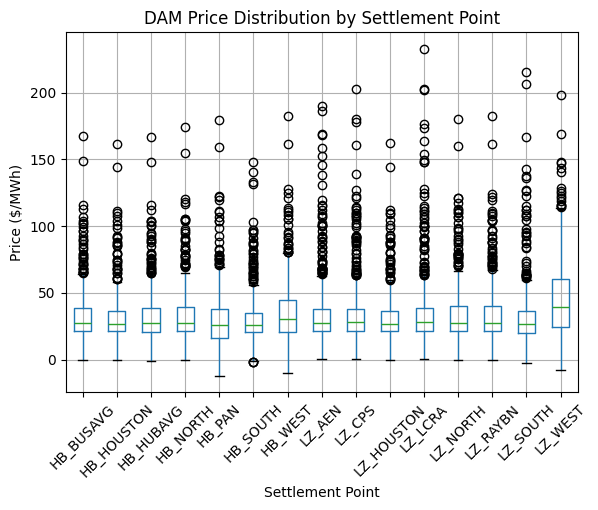

In [32]:
plt.figure(figsize=(12,6))

df.boxplot(
    column='settlement_point_price',
    by='settlement_point',
    rot=45
)

plt.title("DAM Price Distribution by Settlement Point")
plt.suptitle("")

plt.xlabel("Settlement Point")
plt.ylabel("Price ($/MWh)")

plt.show()

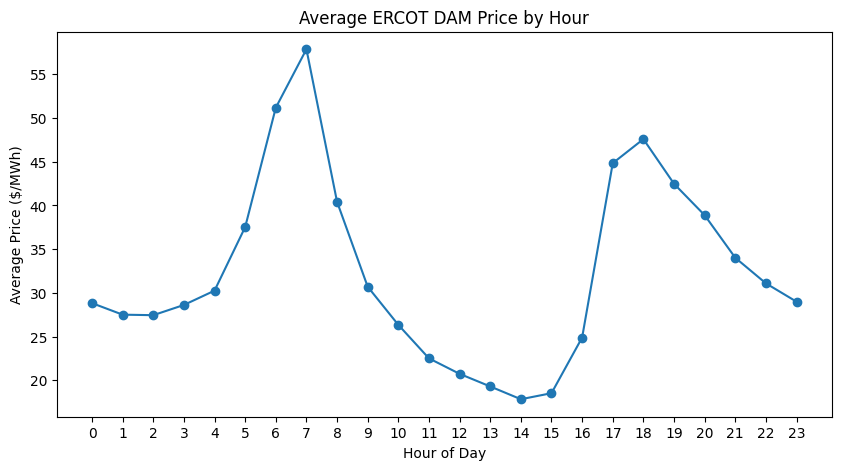

In [33]:
hourly_avg = (
    df.groupby('hour_start')
      ['settlement_point_price']
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker='o'
)

plt.title("Average ERCOT DAM Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price ($/MWh)")

plt.xticks(range(24))

plt.show()

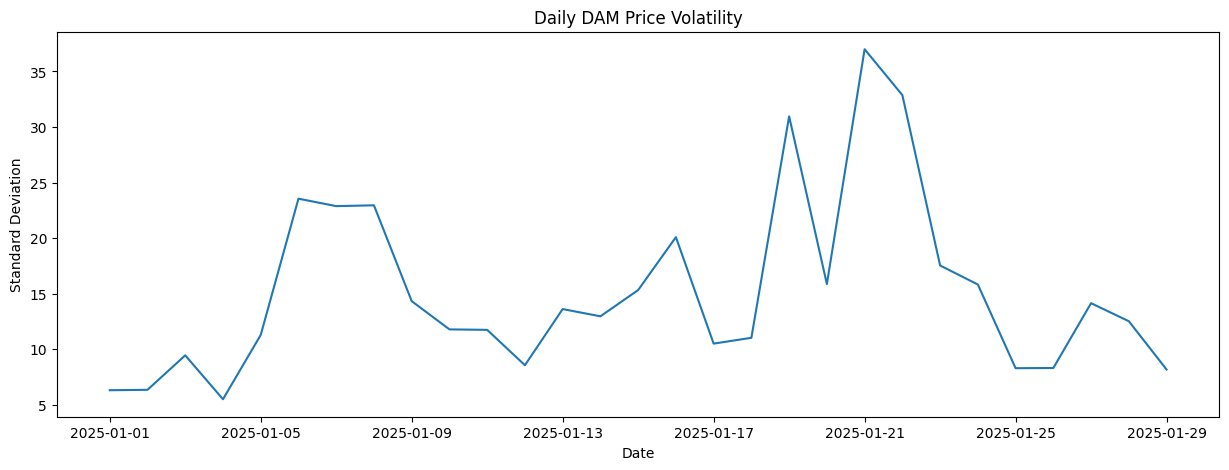

In [34]:
daily_vol = (
    df.groupby('delivery_date')
      ['settlement_point_price']
      .std()
)

plt.figure(figsize=(15,5))

plt.plot(
    daily_vol.index,
    daily_vol.values
)

plt.title("Daily DAM Price Volatility")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")

plt.show()

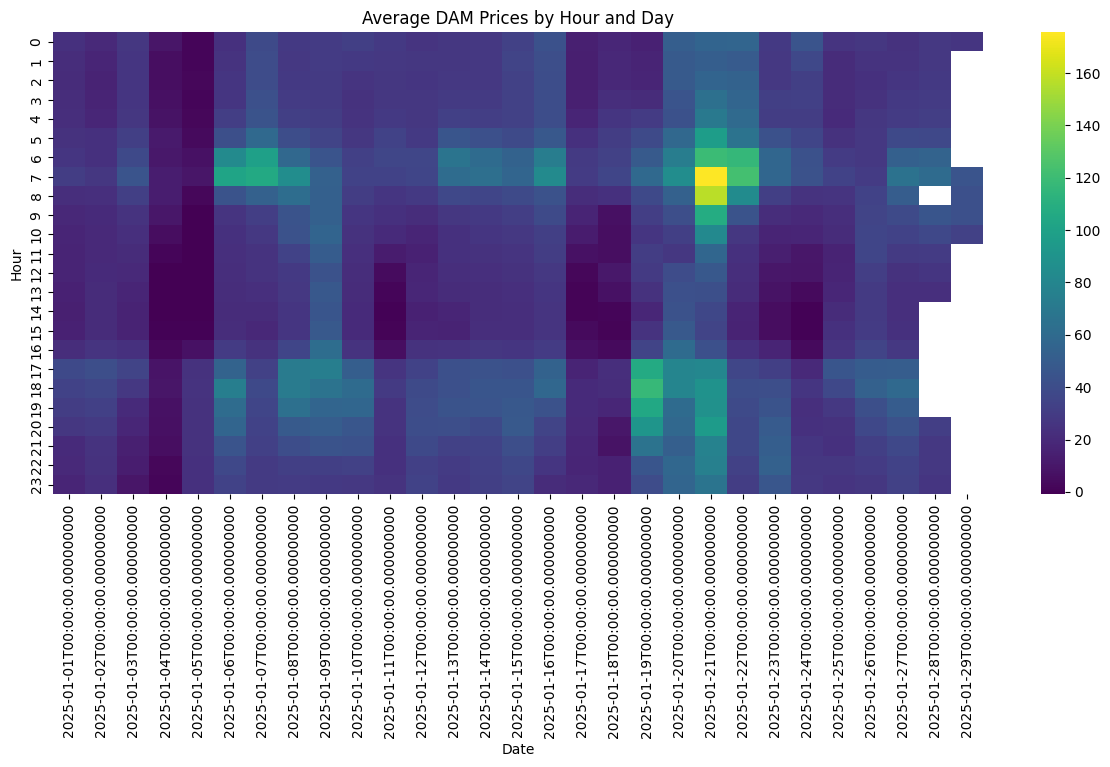

In [35]:
heatmap_data = df.pivot_table(
    index='hour_start',
    columns='delivery_date',
    values='settlement_point_price',
    aggfunc='mean'
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap='viridis'
)

plt.title("Average DAM Prices by Hour and Day")
plt.xlabel("Date")
plt.ylabel("Hour")

plt.show()

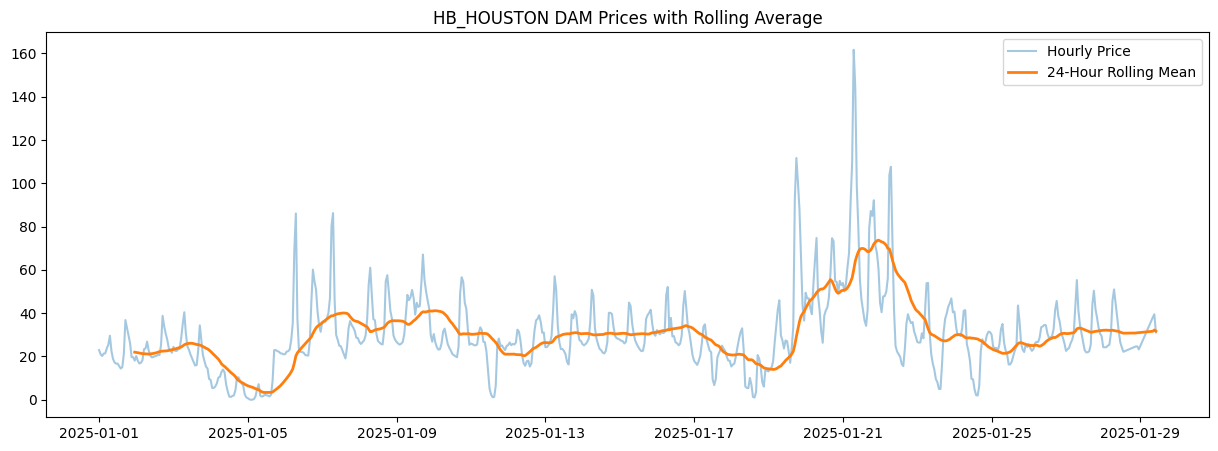

In [36]:
houston = houston.sort_values('datetime_hour')

houston['rolling_mean'] = (
    houston['settlement_point_price']
    .rolling(24)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    houston['datetime_hour'],
    houston['settlement_point_price'],
    alpha=0.4,
    label='Hourly Price'
)

plt.plot(
    houston['datetime_hour'],
    houston['rolling_mean'],
    linewidth=2,
    label='24-Hour Rolling Mean'
)

plt.title("HB_HOUSTON DAM Prices with Rolling Average")
plt.legend()

plt.show()

In [37]:
dallas = pd.read_sql("""
SELECT
    datetime_hour,
    settlement_point_price
FROM staging.stg_ercot_dam_prices
WHERE settlement_point = 'HB_NORTH'
ORDER BY datetime_hour
""", engine)

In [38]:
dallas['datetime_hour'] = pd.to_datetime(
    dallas['datetime_hour']
)

In [39]:
dallas['rolling_avg'] = (
    dallas['settlement_point_price']
    .rolling(24 * 7)
    .mean()
)

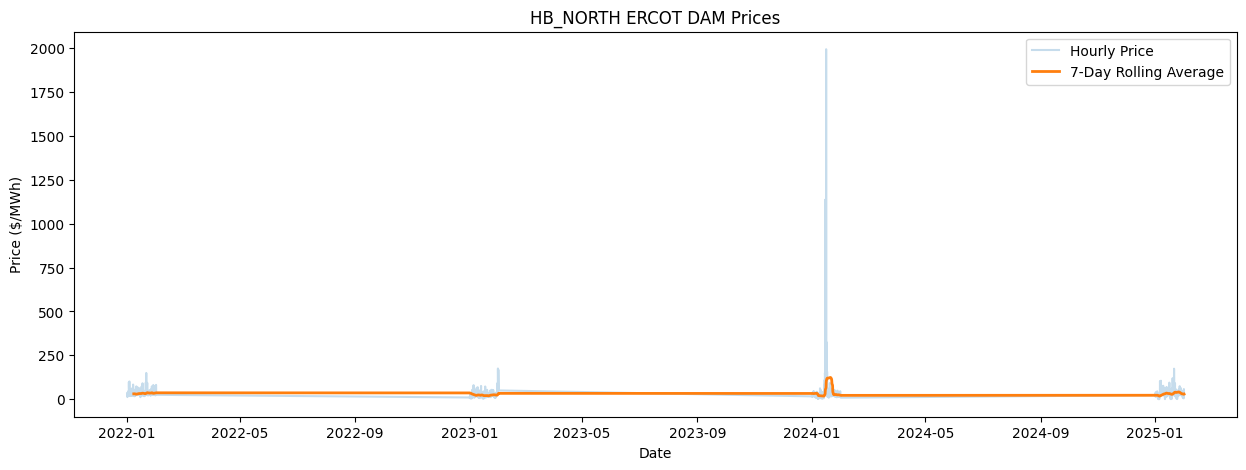

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    dallas['datetime_hour'],
    dallas['settlement_point_price'],
    alpha=0.25,
    label='Hourly Price'
)

plt.plot(
    dallas['datetime_hour'],
    dallas['rolling_avg'],
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.title("HB_NORTH ERCOT DAM Prices")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")

plt.legend()

plt.show()

In [41]:
cap = dallas['settlement_point_price'].quantile(0.99)

dallas['price_capped'] = (
    dallas['settlement_point_price']
    .clip(upper=cap)
)

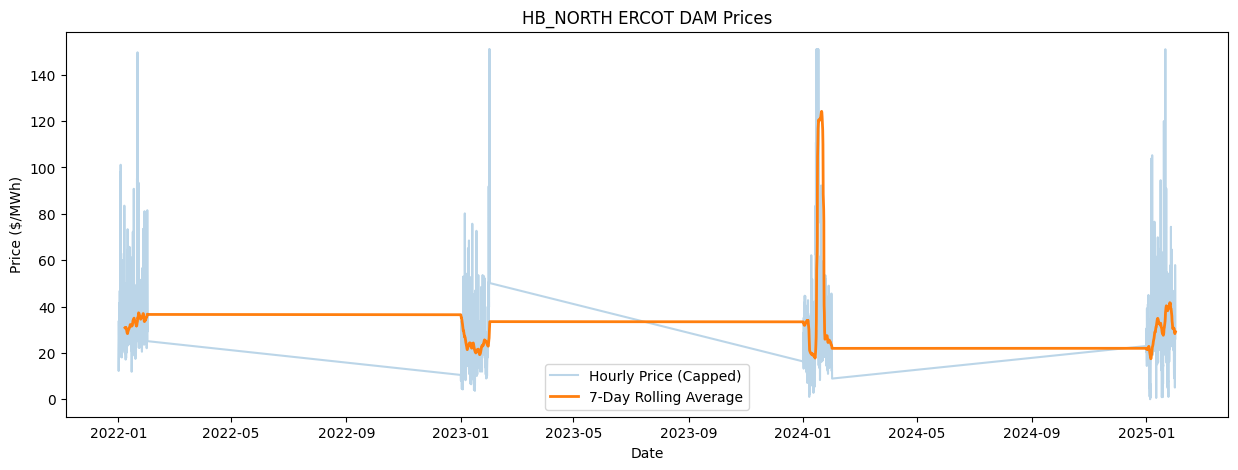

In [42]:
plt.figure(figsize=(15,5))

plt.plot(
    dallas['datetime_hour'],
    dallas['price_capped'],
    alpha=0.3,
    label='Hourly Price (Capped)'
)

plt.plot(
    dallas['datetime_hour'],
    dallas['rolling_avg'],
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.title("HB_NORTH ERCOT DAM Prices")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")

plt.legend()

plt.show()

In [43]:
daily_avg = pd.read_sql("""
SELECT
    delivery_date,
    AVG(settlement_point_price) AS avg_price
FROM staging.stg_ercot_dam_prices
WHERE settlement_point = 'HB_NORTH'
GROUP BY delivery_date
ORDER BY delivery_date
""", engine)

daily_avg['delivery_date'] = pd.to_datetime(
    daily_avg['delivery_date']
)

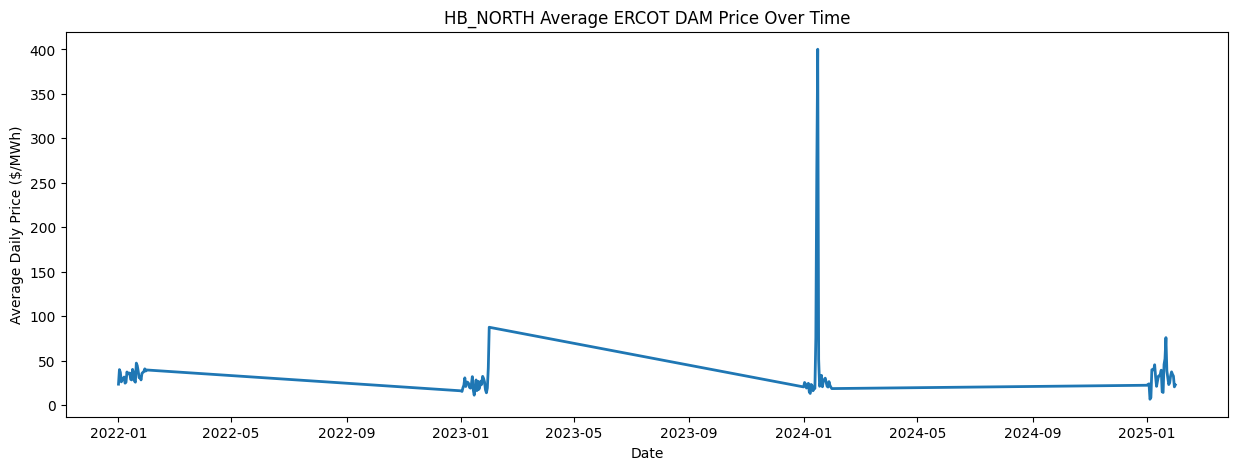

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_avg['delivery_date'],
    daily_avg['avg_price'],
    linewidth=2
)

plt.title("HB_NORTH Average ERCOT DAM Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Daily Price ($/MWh)")

plt.show()

In [45]:
daily_avg['rolling_30d'] = (
    daily_avg['avg_price']
    .rolling(30)
    .mean()
)

In [46]:
daily_avg = daily_avg.sort_values('delivery_date')

daily_avg['date_diff'] = (
    daily_avg['delivery_date']
    .diff()
    .dt.days
)

daily_avg.loc[
    daily_avg['date_diff'] > 7,
    'avg_price'
] = None

#### Weather vs Load

In [47]:
pd.read_sql("""
DESCRIBE staging.stg_weather_texas_hourly
""", engine)

,Field,Type,Null,Key,Default,Extra
0,weather_key,int,NO,PRI,None,auto_increment
1,datetime_hour,datetime,YES,,None,
2,date_key,bigint,YES,,None,
3,hour_start,int,YES,,None,
4,hour_ending,int,YES,,None,
5,city,text,YES,,None,
6,latitude,double,YES,,None,
7,longitude,double,YES,,None,
8,temperature_c,double,YES,,None,
9,relative_humidity_pct,bigint,YES,,None,


In [48]:
pd.read_sql("""
DESCRIBE staging.stg_ercot_region_hourly
""", engine)

,Field,Type,Null,Key,Default,Extra
0,ercot_region_hourly_key,int,NO,PRI,None,auto_increment
1,datetime_hour,datetime,YES,,None,
2,date_key,bigint,YES,,None,
3,hour_start,int,YES,,None,
4,hour_ending,int,YES,,None,
5,region_code,text,YES,,None,
6,region_name,text,YES,,None,
7,metric_code,text,YES,,None,
8,metric_name,text,YES,,None,
9,metric_value,bigint,YES,,None,


In [49]:
query = """
SELECT
    w.datetime_hour,
    w.temperature,
    r.region,
    r.load_mw
FROM staging.stg_weather_texas_hourly w
JOIN staging.stg_ercot_region_hourly r
    ON w.datetime_hour = r.datetime_hour
LIMIT 50000
"""

merged = pd.read_sql(query, engine)

OperationalError: (pymysql.err.OperationalError) (1054, "Unknown column 'w.temperature' in 'field list'")
[SQL: 
SELECT
    w.datetime_hour,
    w.temperature,
    r.region,
    r.load_mw
FROM staging.stg_weather_texas_hourly w
JOIN staging.stg_ercot_region_hourly r
    ON w.datetime_hour = r.datetime_hour
LIMIT 50000
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged['temperature'],
    merged['load_mw'],
    alpha=0.2
)

plt.title("Temperature vs ERCOT Load")
plt.xlabel("Temperature")
plt.ylabel("Load (MW)")

plt.show()

NameError: name 'merged' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
pd.read_sql("""
DESCRIBE staging.stg_weather_texas_hourly;
""", engine)

,Field,Type,Null,Key,Default,Extra
0,weather_key,int,NO,PRI,None,auto_increment
1,datetime_hour,datetime,YES,,None,
2,date_key,bigint,YES,,None,
3,hour_start,int,YES,,None,
4,hour_ending,int,YES,,None,
5,city,text,YES,,None,
6,latitude,double,YES,,None,
7,longitude,double,YES,,None,
8,temperature_c,double,YES,,None,
9,relative_humidity_pct,bigint,YES,,None,


In [ ]:
pd.read_sql("""
DESCRIBE staging.stg_ercot_region_hourly;
""", engine)

In [ ]:
pd.read_sql("""
SELECT *
FROM staging.stg_weather_texas_hourly
LIMIT 5;
""", engine)

In [ ]:
pd.read_sql("""
SHOW COLUMNS FROM staging.stg_ercot_region_hourly;
""", engine)

,Field,Type,Null,Key,Default,Extra
0,ercot_region_hourly_key,int,NO,PRI,None,auto_increment
1,datetime_hour,datetime,YES,,None,
2,date_key,bigint,YES,,None,
3,hour_start,int,YES,,None,
4,hour_ending,int,YES,,None,
5,region_code,text,YES,,None,
6,region_name,text,YES,,None,
7,metric_code,text,YES,,None,
8,metric_name,text,YES,,None,
9,metric_value,bigint,YES,,None,


In [ ]:
pd.read_sql("""
SELECT DISTINCT
    metric_code,
    metric_name,
    metric_units
FROM staging.stg_ercot_region_hourly
ORDER BY metric_name;
""", engine)

,metric_code,metric_name,metric_units
0,DF,Day-ahead demand forecast,megawatthours
1,D,Demand,megawatthours
2,NG,Net generation,megawatthours
3,TI,Total interchange,megawatthours


In [ ]:
from sqlalchemy import text

weather_load = pd.read_sql(
    text("""
    SELECT
        w.datetime_hour,
        w.city,
        w.temperature_c,
        w.apparent_temperature_c,
        r.region_code,
        r.region_name,
        r.metric_value AS load_mw
    FROM staging.stg_weather_texas_hourly w
    JOIN staging.stg_ercot_region_hourly r
        ON w.datetime_hour = r.datetime_hour
    WHERE r.metric_name LIKE :metric
    LIMIT 50000;
    """),
    engine,
    params={"metric": "%Load%"}
)

In [ ]:
pd.read_sql("""
SELECT DISTINCT
    metric_code,
    metric_name,
    metric_units
FROM staging.stg_ercot_region_hourly
ORDER BY metric_name;
""", engine)

,metric_code,metric_name,metric_units
0,DF,Day-ahead demand forecast,megawatthours
1,D,Demand,megawatthours
2,NG,Net generation,megawatthours
3,TI,Total interchange,megawatthours


In [ ]:
weather_load = pd.read_sql("""
SELECT
    w.datetime_hour,
    w.city,
    w.temperature_c,
    w.apparent_temperature_c,
    r.region_code,
    r.region_name,
    r.metric_value AS load_mw
FROM staging.stg_weather_texas_hourly w
JOIN staging.stg_ercot_region_hourly r
    ON w.datetime_hour = r.datetime_hour
WHERE r.metric_name = 'Demand'
LIMIT 50000;
""", engine)

In [ ]:
weather_load.head()
weather_load.shape

(50000, 7)

In [ ]:
weather_load['temp_bin'] = (
    weather_load['temperature_c']
    .round()
)

temp_load = (
    weather_load
    .groupby('temp_bin')['load_mw']
    .mean()
    .reset_index()
)

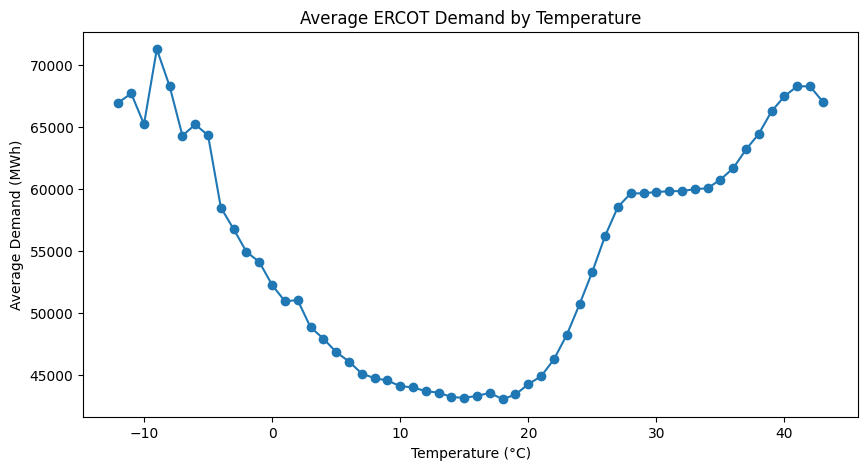

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    temp_load['temp_bin'],
    temp_load['load_mw'],
    marker='o'
)

plt.title("Average ERCOT Demand by Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Demand (MWh)")

plt.show()

In [ ]:
weather_price = pd.read_sql("""
SELECT
    w.datetime_hour,
    AVG(w.temperature_c) AS avg_temperature_c,
    AVG(w.apparent_temperature_c) AS avg_apparent_temperature_c,
    AVG(w.relative_humidity_pct) AS avg_humidity_pct,
    AVG(w.wind_speed_10m_kmh) AS avg_wind_speed_kmh,
    AVG(p.settlement_point_price) AS avg_price
FROM staging.stg_weather_texas_hourly w
JOIN staging.stg_ercot_dam_prices p
    ON w.datetime_hour = p.datetime_hour
GROUP BY w.datetime_hour
ORDER BY w.datetime_hour;
""", engine)

In [ ]:
weather_price.head()
weather_price.shape
weather_price.isnull().sum()

datetime_hour                 0
avg_temperature_c             0
avg_apparent_temperature_c    0
avg_humidity_pct              0
avg_wind_speed_kmh            0
avg_price                     0
dtype: int64

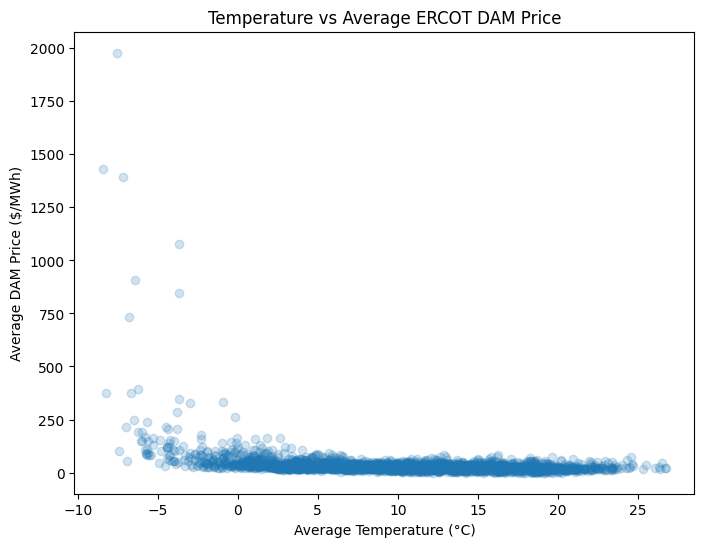

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    weather_price['avg_temperature_c'],
    weather_price['avg_price'],
    alpha=0.2
)

plt.title("Temperature vs Average ERCOT DAM Price")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average DAM Price ($/MWh)")

plt.show()

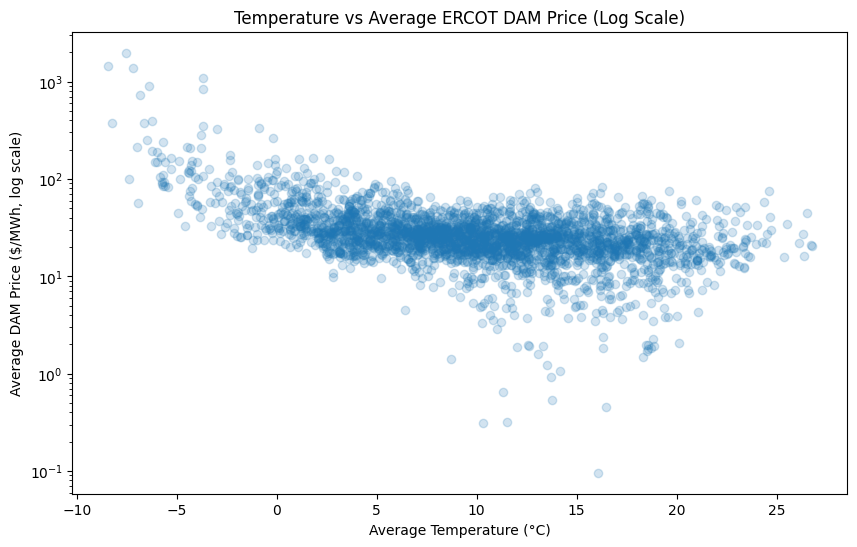

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    weather_price['avg_temperature_c'],
    weather_price['avg_price'],
    alpha=0.2
)

plt.yscale('log')

plt.title("Temperature vs Average ERCOT DAM Price (Log Scale)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average DAM Price ($/MWh, log scale)")

plt.show()